(11)=
# Chapter 11: Linear Algebra & Matrices

**Topics Covered:**
- Vector operations: dot and cross products
- Matrices as 2D NumPy arrays
- Matrix arithmetic and multiplication
- Solving systems of linear equations with `np.linalg.solve`
- Determinant, inverse, and rank
- Chemical engineering application: material balances

## Motivation: Why Do We Need Matrices?

Consider this simple **two-stream mixing problem** from your material-balance course:

```
Feed 1: 40 mol/s,  40% species A  ──►┐
                                     ├──► Mixed stream: F_out mol/s, 55% A
Feed 2: F2 mol/s,  80% species A  ──►┘
```

Two unknowns: **F2** and **F_out**. Two equations:

$$
\text{Overall balance:} \quad 40 + F_2 = F_\text{out}
$$

$$
\text{Species A balance:} \quad 0.40 \times 40 + 0.80\, F_2 = 0.55\, F_\text{out}
$$

With only 2 equations this is manageable by hand. But what if you had **10 streams and 10 species**? Or 50? Substitution would be hopeless.

**The key observation:** both equations are *linear* — no squares, no exponentials. That means the entire system can be written as one compact expression:

$$
\underbrace{\begin{pmatrix} 1 & -1 \\ 0.80 & -0.55 \end{pmatrix}}_{A}
\underbrace{\begin{pmatrix} F_2 \\ F_\text{out} \end{pmatrix}}_{\mathbf{x}}
=
\underbrace{\begin{pmatrix} -40 \\ -16 \end{pmatrix}}_{\mathbf{b}}
$$

**How do we solve for $\mathbf{x}$?** Multiply both sides on the left by $A^{-1}$ (the *inverse* of $A$):

$$
A^{-1} A\, \mathbf{x} = A^{-1} \mathbf{b}
\quad\Longrightarrow\quad
I\, \mathbf{x} = A^{-1} \mathbf{b}
\quad\Longrightarrow\quad
\boxed{\mathbf{x} = A^{-1} \mathbf{b}}
$$

This is the matrix equivalent of dividing both sides of a scalar equation by $a$: $ax = b \Rightarrow x = b/a$.  
In Python, `np.linalg.solve(A, b)` computes $A^{-1}\mathbf{b}$ for us — efficiently and accurately — in one call.

In [1]:
import numpy as np

# Two-stream mixer: find F2 and F_out
# Equation 1 (overall):    F2 - F_out = -40       →  coefficients: [1, -1]
# Equation 2 (species A):  0.80*F2 - 0.55*F_out = -16  →  coefficients: [0.80, -0.55]

A = np.array([[ 1.00, -1.00],
              [ 0.80, -0.55]])

b = np.array([-40.0, -16.0])

x = np.linalg.solve(A, b)

print(x)
F2, F_out = x

print(f"F2    = {F2:.2f} mol/s")
print(f"F_out = {F_out:.2f} mol/s")
# print(f"\nVerification: A @ x = {A @ x}  (should match b = {b})")

[24. 64.]
F2    = 24.00 mol/s
F_out = 64.00 mol/s


(11.1)=
## 11.1 Vector Operations: Dot and Cross Products

Before working with matrices, it helps to understand **vectors** — the building blocks of linear algebra.

A vector in NumPy is simply a 1D array:
```python
u = np.array([1, 2, 3])
```

**Dot product**

The dot product of two vectors $\mathbf{u}$ and $\mathbf{v}$ is a **scalar**:

$$
\mathbf{u} \cdot \mathbf{v} = \sum_i u_i v_i = |\mathbf{u}||\mathbf{v}|\cos\theta
$$

$$
\mathbf{u}\cdot\mathbf{v}
=
u_1v_1 + u_2v_2 + \dots + u_nv_n
$$

- Result is zero when the vectors are **perpendicular** ($\theta = 90°$)
- np.dot()

Geometric Meaning

The dot product measures **how much one vector aligns with another**.

- Maximum positive → vectors point in the same direction  
- Zero → vectors are **perpendicular** ($\theta = 90^\circ$)  
- Negative → vectors point in opposite directions  



**Cross product**

The cross product of two 3D vectors is a **vector** perpendicular to both:

$$
\mathbf{u} \times \mathbf{v} =
\begin{vmatrix}
\mathbf{i} & \mathbf{j} & \mathbf{k} \\
u_1 & u_2 & u_3 \\
v_1 & v_2 & v_3
\end{vmatrix}
$$

$$
\mathbf{u} \times \mathbf{v} =
\mathbf{i}(u_2v_3-u_3v_2)
-
\mathbf{j}(u_1v_3-u_3v_1)
+
\mathbf{k}(u_1v_2-u_2v_1)
$$

- Magnitude $|\mathbf{u} \times \mathbf{v}| = |\mathbf{u}||\mathbf{v}|\sin\theta$ equals the area of the parallelogram spanned by $\mathbf{u}$ and $\mathbf{v}$
- Perpendicular to both vectors
- Determined by **right-hand rule**
- Result is zero when vectors are **parallel**
- np.cross()



In [2]:
import numpy as np

u = np.array([1, 2, 3])
v = np.array([4, 5, 6])

# ── Dot product ───────────────────────────────────────────────────────────
dot = np.dot(u, v)              # or: u @ v
print(f"u = {u}")
print(f"v = {v}")
print(f"\nDot product  u · v = {dot}")
print(f"  (manual: {u[0]*v[0]} + {u[1]*v[1]} + {u[2]*v[2]} = {u[0]*v[0]+u[1]*v[1]+u[2]*v[2]})")

u = [1 2 3]
v = [4 5 6]

Dot product  u · v = 32
  (manual: 4 + 10 + 18 = 32)


In [6]:
np.linalg.norm(u)

3.7416573867739413

In [12]:
cos_theta = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
theta = np.arccos(cos_theta)
print(np.degrees(theta))

12.933154491899135


In [6]:
# Angle between vectors
cos_theta = dot / (np.linalg.norm(u) * np.linalg.norm(v))
theta_deg = np.degrees(np.arccos(cos_theta))
print(f"  Angle between u and v: {theta_deg:.2f}°")

  Angle between u and v: 12.93°


In [7]:
# Perpendicular vectors → dot = 0
a = np.array([1, 0, 0])
b = np.array([0, 1, 0])
print(f"\nPerpendicular check: {a} · {b} = {np.dot(a, b)}  (expected 0)")


Perpendicular check: [1 0 0] · [0 1 0] = 0  (expected 0)


In [13]:

# ── Cross product ─────────────────────────────────────────────────────────
cross = np.cross(u, v)
print(f"\nCross product  u × v = {cross}")

# Verify perpendicularity: cross product is perpendicular to both u and v
print(f"  cross · u = {np.dot(cross, u)}  (should be 0)")
print(f"  cross · v = {np.dot(cross, v)}  (should be 0)")

# Magnitude = area of parallelogram
area = np.linalg.norm(cross)
print(f"  |u × v| = {area:.4f}  (area of parallelogram spanned by u and v)")

# Parallel vectors → cross = [0,0,0]
p = np.array([1, 2, 3])
q = np.array([2, 4, 6])   # q = 2p
print(f"\nParallel check: {p} × {q} = {np.cross(p, q)}  (expected [0,0,0])")



Cross product  u × v = [-3  6 -3]
  cross · u = 0  (should be 0)
  cross · v = 0  (should be 0)
  |u × v| = 7.3485  (area of parallelogram spanned by u and v)

Parallel check: [1 2 3] × [2 4 6] = [0 0 0]  (expected [0,0,0])


In [5]:
cross

array([-3,  6, -3])

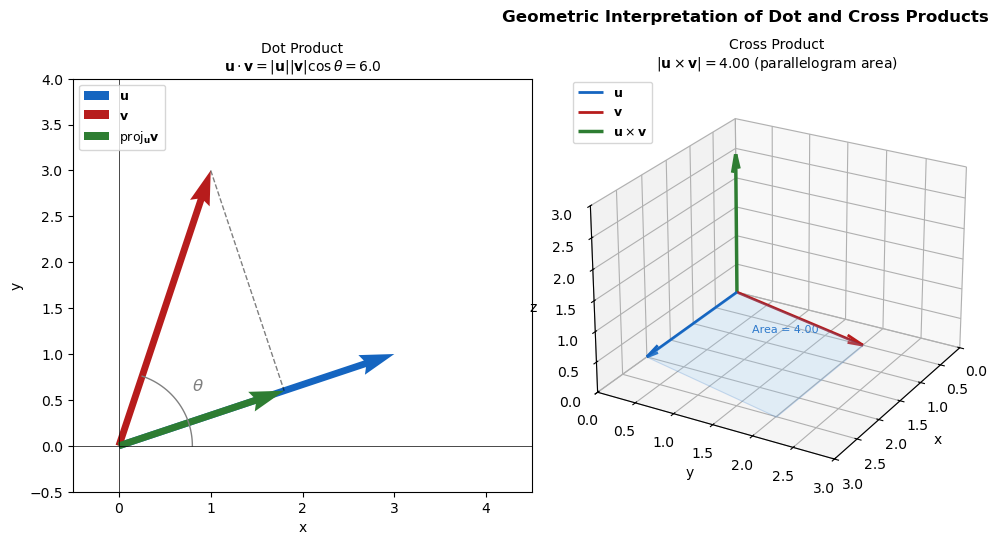

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Use simple 2D vectors for geometry clarity
u2 = np.array([3.0, 1.0])
v2 = np.array([1.0, 3.0])

fig = plt.figure(figsize=(15, 5))

# ── Panel 1: Dot product — projection ────────────────────────────────────
ax1 = fig.add_subplot(131)

origin = np.array([0, 0])
ax1.quiver(*origin, *u2, angles='xy', scale_units='xy', scale=1,
           color='#1565C0', width=0.015, label=r'$\mathbf{u}$')
ax1.quiver(*origin, *v2, angles='xy', scale_units='xy', scale=1,
           color='#B71C1C', width=0.015, label=r'$\mathbf{v}$')

# Projection of v onto u
u2_hat = u2 / np.linalg.norm(u2)
proj_len = np.dot(v2, u2_hat)
proj_vec = proj_len * u2_hat
ax1.quiver(*origin, *proj_vec, angles='xy', scale_units='xy', scale=1,
           color='#2E7D32', width=0.015, label=r'proj$_{\mathbf{u}}\mathbf{v}$')

# Dashed line from v tip to projection
ax1.plot([v2[0], proj_vec[0]], [v2[1], proj_vec[1]],
         'k--', linewidth=1, alpha=0.5)

# Angle arc
theta = np.linspace(0, np.arctan2(v2[1], v2[0]), 30)
r = 0.8
ax1.plot(r*np.cos(theta), r*np.sin(theta), 'gray', linewidth=1)
mid = len(theta)//2
ax1.text(r*np.cos(theta[mid])*1.25, r*np.sin(theta[mid])*1.25,
         r'$\theta$', fontsize=12, color='gray')

# Dot product annotation
dot2 = np.dot(u2, v2)
ax1.set_title(f'Dot Product\n'
              f'$\\mathbf{{u}}\\cdot\\mathbf{{v}}=|\\mathbf{{u}}||\\mathbf{{v}}|\\cos\\theta={dot2:.1f}$',
              fontsize=10)
ax1.set_xlim(-0.5, 4.5); ax1.set_ylim(-0.5, 4.0)
ax1.set_aspect('equal'); ax1.axhline(0, color='k', lw=0.5); ax1.axvline(0, color='k', lw=0.5)
ax1.legend(loc='upper left', fontsize=9)
ax1.set_xlabel('x'); ax1.set_ylabel('y')


# ── Panel 2: Cross product — 3D parallelogram + result vector ────────────
ax2 = fig.add_subplot(132, projection='3d')

u3 = np.array([2.0, 0.0, 0.0])
v3 = np.array([0.5, 2.0, 0.0])
w3 = np.cross(u3, v3)          # points in +z direction

# Draw u and v
ax2.quiver(0,0,0, *u3, color='#1565C0', linewidth=2, arrow_length_ratio=0.12, label=r'$\mathbf{u}$')
ax2.quiver(0,0,0, *v3, color='#B71C1C', linewidth=2, arrow_length_ratio=0.12, label=r'$\mathbf{v}$')

# Draw cross product vector (scaled for visibility)
scale = 0.6
ax2.quiver(0,0,0, *(w3*scale), color='#2E7D32', linewidth=2.5,
           arrow_length_ratio=0.12, label=r'$\mathbf{u}\times\mathbf{v}$')

# Parallelogram faces
corners = np.array([[0,0,0], u3, u3+v3, v3])
poly = Poly3DCollection([corners], alpha=0.2, facecolor='#90CAF9', edgecolor='#1565C0', linewidth=0.8)
ax2.add_collection3d(poly)

# Annotate area
area2 = np.linalg.norm(w3)
ax2.text(1.0, 0.8, 0.1, f'Area = {area2:.2f}', fontsize=8, color='#1565C0')
ax2.set_xlim(0, 3); ax2.set_ylim(0, 3); ax2.set_zlim(0, 3)
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')
ax2.set_title(f'Cross Product\n'
              f'$|\\mathbf{{u}}\\times\\mathbf{{v}}|={area2:.2f}$ (parallelogram area)', fontsize=10)
ax2.legend(fontsize=9, loc='upper left')
ax2.view_init(elev=25, azim=30)

plt.suptitle('Geometric Interpretation of Dot and Cross Products',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


(11.2)=
## 11.2 Matrices as 2D NumPy Arrays

A **matrix** is just a rectangular array of numbers arranged in rows and columns. In NumPy, it is identical to a 2D array — there is no separate "matrix" type.

$$
A = \begin{pmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \\ 7 & 8 & 9 \end{pmatrix} \quad \leftarrow \text{3×3 matrix, created with } \texttt{np.array}
$$

Key terminology:

| Term | Shape | How to create |
|------|-------|---------------|
| **Row vector** | `(1, n)` — 1 row, n columns | `np.array([[1, 2, 3]])` — note the **double brackets** |
| **Column vector** | `(n, 1)` — n rows, 1 column | `np.array([[1], [2], [3]])` |
| **Square matrix** | `(n, n)` | `np.array([[...], [...]])` |
| **Identity matrix** $I$ | `(n, n)` diagonal 1s | `np.eye(n)` |

> **Note:** A plain 1D array like `np.array([1, 2, 3])` has shape `(3,)` — it is **not** a row or column vector. It has no orientation. Use double brackets `[[...]]` to make a true 2D row vector.

In [4]:
import numpy as np
# A 3×3 matrix (same as a 2D array)
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
print("Matrix A:")
print(A)
print("Shape:", A.shape)   # (rows, cols)

Matrix A:
[[1 2 3]
 [4 5 6]
 [7 8 9]]
Shape: (3, 3)


**Three ways to store "a list of numbers" — and why the shape matters:**

In [5]:
# 1D array
v_1d = np.array([1, 2, 3])
print("\n1D array:", v_1d, "  shape:", v_1d.shape)


1D array: [1 2 3]   shape: (3,)


In [6]:
# Row vector (2D)
v_row = np.array([[1, 2, 3]])
print("\nRow vector (2D):", v_row, "  shape:", v_row.shape)


Row vector (2D): [[1 2 3]]   shape: (1, 3)


In [7]:
# Column vector (2D, explicit)
v_col = np.array([[1], [2], [3]])
print("\nColumn vector:\n", v_col, "  shape:", v_col.shape)


Column vector:
 [[1]
 [2]
 [3]]   shape: (3, 1)


In [8]:
# Identity matrix
I = np.eye(3)
print("\nIdentity matrix I:")
print(I)


Identity matrix I:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


(11.3)=
## 11.3 Matrix Arithmetic and Multiplication

Element-wise operations (`+`, `-`, `*`, `/`) work the same as with regular arrays — they act on corresponding elements.

**Matrix multiplication** is different. The `@` operator performs the true mathematical dot product of rows and columns:

$$
(AB)_{ij} = \sum_k A_{ik} B_{kj}
$$

| Operation | Symbol | Meaning |
|-----------|--------|---------|
| Element-wise add/subtract | `A + B`, `A - B` | Add matching elements |
| Element-wise multiply | `A * B` | Multiply matching elements (NOT matrix mult) |
| **Matrix multiply** | `A @ B` | Dot product (row × column) |
| Scalar multiply | `c * A` | Scale every element |
| Transpose | `A.T` | Flip rows ↔ columns |

In [9]:
A = np.array([[1, 2],
              [3, 4]])

B = np.array([[2, 2],
              [3, 1]])


print("A =\n", A)
print("B =\n", B)

A =
 [[1 2]
 [3 4]]
B =
 [[2 2]
 [3 1]]


In [10]:
# Element-wise multiply (NOT matrix multiplication)
print("\nA * B  (element-wise):\n", A * B)

# True matrix multiplication
print("\nA @ B  (matrix multiply):\n", A @ B)


A * B  (element-wise):
 [[2 4]
 [9 4]]

A @ B  (matrix multiply):
 [[ 8  4]
 [18 10]]


In [11]:
# Scalar multiply
print("\n3 * A:\n", 3 * A)

# Transpose
print("\nA.T (transpose):\n", A.T)


3 * A:
 [[ 3  6]
 [ 9 12]]

A.T (transpose):
 [[1 3]
 [2 4]]


In [12]:
C = A @ B

print("\nA @ B  (matrix multiply):\n", C)

I = np.eye(2)
print("\nC @ I =\n", C @ I)


A @ B  (matrix multiply):
 [[ 8  4]
 [18 10]]

C @ I =
 [[ 8.  4.]
 [18. 10.]]


(11.4)=
## 11.4 Solving Systems of Linear Equations

A system of linear equations can always be written as $A\mathbf{x} = \mathbf{b}$:

$$
\begin{cases}
2x + y = 5 \\
5x + 3y = 13
\end{cases}
\quad \Longrightarrow \quad
\underbrace{\begin{pmatrix} 2 & 1 \\ 5 & 3 \end{pmatrix}}_{A}
\underbrace{\begin{pmatrix} x \\ y \end{pmatrix}}_{\mathbf{x}}
=
\underbrace{\begin{pmatrix} 5 \\ 13 \end{pmatrix}}_{\mathbf{b}}
$$

**`np.linalg.solve(A, b)`** solves for $\mathbf{x}$ directly — no elimination by hand required.

```python
x = np.linalg.solve(A, b)
```

**Shape convention for `b`:** Even though $\mathbf{b}$ is mathematically a column vector, `np.linalg.solve` expects it as a **1D array** with shape `(n,)` — not shape `(n, 1)`. The solution `x` it returns is also 1D.

In [13]:
# b is a 1D array — np.linalg.solve expects this, not a column vector
b = np.array([5, 13])
# b = np.array([[5], [13]])  # This is a 2D column vector, which will cause an error
print("b shape:", b.shape)   # (2,) — 1D, not (2,1)

# Solve for x = [x, y]
x = np.linalg.solve(A, b)
print("Solution x =", x)
print(f'x shape: {x.shape}')  # Should be (2,), not (2,1)
print(f"  x = {x[0]}")
print(f"  y = {x[1]}")

# Verify: A @ x should equal b
print("\nVerification: A @ x =", A @ x)
print("b            =", b)

b shape: (2,)
Solution x = [3. 1.]
x shape: (2,)
  x = 3.0
  y = 1.0000000000000002

Verification: A @ x = [ 5. 13.]
b            = [ 5 13]


### 11.3.1 Scaling Up: 3 Equations, 3 Unknowns

The same workflow applies for larger systems. Suppose:

$$
\begin{cases}
3x_1 + x_2 - x_3 = 2 \\
x_1 + 4x_2 + x_3 = 12 \\
2x_1 - x_2 + 5x_3 = 10
\end{cases}
$$

In [14]:
# 3×3 system
A3 = np.array([[ 3,  1, -1],
               [ 1,  4,  1],
               [ 2, -1,  5]])

b3 = np.array([2, 12, 10])

x = np.linalg.solve(A3, b3) # x = [x1, x2, x3]
print("Solution:", x)
print(f"  x1 = {x[0]:.4f}")
print(f"  x2 = {x[1]:.4f}")
print(f"  x3 = {x[2]:.4f}")

# Verify
# print("\nVerification: A @ x =", A3 @ x)
# print("b                   =", b3)

Solution: [0.63768116 2.28985507 2.20289855]
  x1 = 0.6377
  x2 = 2.2899
  x3 = 2.2029


(11.5)=
## 11.5 Determinant, Inverse, and Rank

Three important properties of square matrices:

| Property | Function | Meaning |
|----------|----------|---------|
| **Determinant** | `np.linalg.det(A)` | Scalar; $\det(A) = 0$ → no unique solution |
| **Inverse** | `np.linalg.inv(A)` | $A^{-1}$ such that $A A^{-1} = I$ |
| **Rank** | `np.linalg.matrix_rank(A)` | Number of linearly independent rows/columns |

**Key rule:** A system $A\mathbf{x} = \mathbf{b}$ has a unique solution **if and only if** $\det(A) \neq 0$ (equivalently, A has full rank).


$$
A =
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
$$




---

**Determinant 

$$
\det(A) = ad - bc
$$


---

**Inverse — Solving Linear Systems**



If $A^{-1}$ exists, you can solve

$$
A\mathbf{x} = \mathbf{b}
$$

by multiplying both sides:

$$
\mathbf{x} = A^{-1}\mathbf{b}
$$

$$
A^{-1} =
\frac{1}{ad - bc}
\begin{bmatrix}
d & -b \\
-c & a
\end{bmatrix}
$$

But **not every matrix has an inverse**. A matrix is invertible **only if**

- determinant ≠ 0
- (full rank, rows/columns are independent)

All three conditions are actually equivalent statements.

a x = b
x = b/a
what if a = 0 
what if a = 0 b = 0

A x = b
det(A) = 0 

In [15]:
A = np.array([[2, 1],
              [5, 3]])

In [16]:
# Determinant
det_A = np.linalg.det(A)
print(f"det(A) = {det_A:.4f}")
print("System has unique solution:", det_A != 0)


det(A) = 1.0000
System has unique solution: True


In [17]:
# Inverse
A_inv = np.linalg.inv(A)
print("\nA_inv =\n", A_inv)

# Verify: A @ A_inv should be the identity
print("\nA @ A_inv =\n", np.round(A @ A_inv, 10))


A_inv =
 [[ 3. -1.]
 [-5.  2.]]

A @ A_inv =
 [[ 1.  0.]
 [-0.  1.]]


In [18]:
# Rank
rank_A = np.linalg.matrix_rank(A)
print(f"\nrank(A) = {rank_A}  (full rank: {rank_A == A.shape[0]})")


rank(A) = 2  (full rank: True)


In [19]:
B = np.array([[2, 1],
              [4, 2]])

rank_B = np.linalg.matrix_rank(B)
print(f"\nrank(B) = {rank_B}  (full rank: {rank_B == B.shape[0]})")


rank(B) = 1  (full rank: False)


In [20]:
# Singular matrix: rows are linearly dependent (row 2 = 2 × row 1)
A_singular = np.array([[1, 2],
                       [2, 4]])

print("Singular matrix A_singular =\n", A_singular)
print(f"det(A_singular) = {np.linalg.det(A_singular):.6f}")
print(f"rank(A_singular) = {np.linalg.matrix_rank(A_singular)}")

# Attempting to solve will raise an error (LinAlgError: Singular matrix)
try:
    x_sing = np.linalg.solve(A_singular, np.array([1, 2]))
    print("Solution:", x_sing)
except np.linalg.LinAlgError as e:
    print(f"\nError: {e}  ← cannot solve a singular system!")

Singular matrix A_singular =
 [[1 2]
 [2 4]]
det(A_singular) = 0.000000
rank(A_singular) = 1

Error: Singular matrix  ← cannot solve a singular system!


(11.6)=
## 11.6 Chemical Engineering Application: Material Balances

(11.6.1)=
### 11.6.1 Three-Stream Mixer-Splitter

**Steady-state material balances** on a process network are linear equations — a perfect match for `np.linalg.solve`.

Consider a simple process with three unknown flow rates ($F_1$, $F_2$, $F_3$) in mol/s:

```
F1 (A 40%)  ──►┌──────────┐
               │  Mixer   ├──► F3 ──► ┌──────────┐──► F5 (known: 80 mol/s)
F2 (A 80%)  ──►└──────────┘  (A 60%)  │ Splitter │
                                      └──────────┘──► F4 (known: 20 mol/s)
```

Balance equations (total and component):

1. **Overall balance (Mixer):** $F_1 + F_2 = F_3$
2. **Component A balance (Mixer):** $0.4 F_1 + 0.8 F_2 = 0.6 F_3$
3. **Overall balance (Splitter):** $F_3 = F_4 + F_5 = 100$ mol/s

With $F_4 = 20$ and $F_5 = 80$, we know $F_3 = 100$. The unknowns are $F_1$ and $F_2$.

Rearranging equations 1 and 2 with $F_3 = 100$:

$$
\begin{cases}
F_1 + F_2 = 100 \\
0.4 F_1 + 0.8 F_2 = 60
\end{cases}
$$

In [21]:
A_mat = np.array([[1.0,  1.0],
                  [0.4,  0.8]])

b_mat = np.array([100.0, 60.0])

A_inv = np.linalg.inv(A_mat)
x = A_inv @ b_mat
print(x)

[50. 50.]


In [22]:
# Material balance on mixer
# Unknowns: F1 (mol/s), F2 (mol/s)
# Known: F3 = 100 mol/s,  x_A in feed 1 = 0.4,  x_A in feed 2 = 0.8,  x_A in F3 = 0.6

# Equations:
#   F1 + F2 = 100            (overall balance)
#   0.4*F1 + 0.8*F2 = 60    (component A balance: 0.6 * 100 = 60)

A_mat = np.array([[1.0,  1.0],
                  [0.4,  0.8]])

b_mat = np.array([100.0, 60.0])

# Solve
F = np.linalg.solve(A_mat, b_mat)
F1, F2 = F
print(f"F1 = {F1:.2f} mol/s")
print(f"F2 = {F2:.2f} mol/s")
print(f"F3 = {F1 + F2:.2f} mol/s  (check: should be 100)")

# Verify balances
print("\n--- Verification ---")
print(f"Overall balance:     F1 + F2 = {F1 + F2:.2f}  (expected 100)")
print(f"Component A balance: 0.4*F1 + 0.8*F2 = {0.4*F1 + 0.8*F2:.2f}  (expected 60)")

# Mole fraction check
x_A_F3 = (0.4*F1 + 0.8*F2) / (F1 + F2)
print(f"\nComposition of F3: x_A = {x_A_F3:.2f}  (expected 0.60)")

F1 = 50.00 mol/s
F2 = 50.00 mol/s
F3 = 100.00 mol/s  (check: should be 100)

--- Verification ---
Overall balance:     F1 + F2 = 100.00  (expected 100)
Component A balance: 0.4*F1 + 0.8*F2 = 60.00  (expected 60)

Composition of F3: x_A = 0.60  (expected 0.60)


(11.6.2)=
### 11.6.2 Energy Balance in a Heat Exchange Network

**Process Description**

Three liquid streams pass through a heat-exchange network before entering a reactor. We want to find the **unknown outlet temperatures** $T_1, T_2, T_3$ (°C).

```


                           ┌──────────────────────┐
Stream 1 (mCp=5)           │  HX-12 (UA = 2 kW/°C)│
T1,in = 100°C  ───────────►│  Heat exchange 1 ↔ 2 │──────────►  T1 (out)
                           └──────────────────────┘
                                      ▲     │
                                      │     │    
                                      │     │
                                      │     │
Stream 2 (mCp=4)                      │     │
T2,in = 60°C  ────────────────────────┘     │
                                            │
                                            │   (same stream continues)
                                            ▼
                           ┌──────────────────────┐
                           │  HX-23 (UA = 1 kW/°C)│
                           │  Heat exchange 2 ↔ 3 │──────────►  T2 (out)
                           └──────────────────────┘
                                      ▲
                                      │
Stream 3 (mCp=6)                      │
T3,in = 150°C ────────────────────────┘────────────►  T3 (out)


                    T1 (out) ─┐
                    T2 (out) ─┼──► Reactor feed (mixed or separate feeds)
                    T3 (out) ─┘

```
**Assumptions:** steady state, no heat loss, constant heat capacities, linear heat transfer between streams.


**Given Parameters**

| | Stream 1 | Stream 2 | Stream 3 |
|---|---|---|---|
| $\dot{m} C_p$ (kW/°C) | 5 | 4 | 6 |
| $T_\text{in}$ (°C) | 100 | 60 | 150 |

Heat exchanger conductances: $UA_{1\text{-}2} = 2$ kW/°C,  $UA_{2\text{-}3} = 1$ kW/°C


Step 1 — Energy Balance on Each Stream

Each stream: $\dot{m}C_p (T_\text{in} - T_\text{out}) = \sum Q_\text{exchanged}$, where $Q = UA(T_i - T_j)$.

**Stream 1:**
$$5(100 - T_1) = 2(T_1 - T_2) \quad\Longrightarrow\quad 7T_1 - 2T_2 = 500$$

**Stream 2:**
$$4(60 - T_2) + 2(T_1 - T_2) = 1(T_2 - T_3) \quad\Longrightarrow\quad 2T_1 - 7T_2 + T_3 = -240$$

**Stream 3:**
$$6(150 - T_3) + 1(T_2 - T_3) = 0 \quad\Longrightarrow\quad T_2 - 7T_3 = -900$$


Step 2 — Matrix Form $A\mathbf{T} = \mathbf{b}$

$$
\underbrace{\begin{pmatrix} 7 & -2 & 0 \\ 2 & -7 & 1 \\ 0 & 1 & -7 \end{pmatrix}}_{A}
\underbrace{\begin{pmatrix} T_1 \\ T_2 \\ T_3 \end{pmatrix}}_{\mathbf{T}}
=
\underbrace{\begin{pmatrix} 500 \\ -240 \\ -900 \end{pmatrix}}_{\mathbf{b}}
$$

In [23]:
# Heat exchange network energy balance
# Unknowns: T1, T2, T3 (outlet temperatures, °C)

A_net = np.array([[ 7, -2,  0],
                  [ 2, -7,  1],
                  [ 0,  1, -7]])

b_net = np.array([500, -240, -900], dtype=float)

print(f"det(A) = {np.linalg.det(A_net):.2f}  → unique solution exists")

T = np.linalg.solve(A_net, b_net)
print(f"\nOutlet temperatures:")
print(f"  T1 = {T[0]:.2f} °C")
print(f"  T2 = {T[1]:.2f} °C")
print(f"  T3 = {T[2]:.2f} °C")

# Verify
print(f"\nVerification: A @ T = {np.round(A_net @ T, 6)}")
print(f"b               = {b_net}")

det(A) = 308.00  → unique solution exists

Outlet temperatures:
  T1 = 94.68 °C
  T2 = 81.36 °C
  T3 = 140.19 °C

Verification: A @ T = [ 500. -240. -900.]
b               = [ 500. -240. -900.]


(11.6.3)=
### 11.6.3 Four-Component Separation Train: 5×5 System

A process separates a feed stream into four product streams using a series of splitters. We have **5 unknown flow rates** and can write 5 independent mass balance equations.

```
                          ┌──────────┐
                     ┌───►│ Split-1  ├──► F2 (product A, 30% of S1)
Feed F1 (100 mol/s) ─┤    └──────────┘
   xA=0.50           │         │ S1
   xB=0.30           │         ▼
   xC=0.20           │   ┌──────────┐
                     │   │ Split-2  ├──► F3 (product B)
                     │   └──────────┘
                     │         │ S2
                     │         ▼
                     │   ┌──────────┐
                     └──►│  Mixer   ├──► F5 (recycle, known: 10 mol/s, xA=0.6)
                         └──────────┘
                              │
                              ▼ F4 (bottoms)
```

**Unknowns:** $F_2, F_3, F_4, S_1, S_2$ (mol/s)

**Known:** $F_1 = 100$ mol/s with $x_A = 0.50$, $x_B = 0.30$, $x_C = 0.20$; $F_5 = 10$ mol/s with $x_A = 0.60$; Split-1 sends 40% to $F_2$; Split-2 sends 50% of its inlet to $F_3$.

**5 equations:**
1. Overall balance on Split-1: $S_1 = F_1 - F_2$
2. Split-1 specification: $F_2 = 0.40\, F_1$ → rearranged: $F_2 - 0.40\,F_1 = 0$, but $F_1$ is known, so: $F_2 = 40$; embed as $F_2 = 0.40 \times 100$
3. Overall balance on Split-2: $F_3 + S_2 = S_1$
4. Split-2 specification: $F_3 = 0.50\, S_1$
5. Overall balance on Mixer: $S_2 + F_5 = F_4 + F_5$ → $F_4 = S_2$

Rewriting as $A\mathbf{x} = \mathbf{b}$ with $\mathbf{x} = [F_2, F_3, F_4, S_1, S_2]^T$:

| Eq. | Equation | Variables involved |
|-----|----------|--------------|
| 1 | $F_2 = 40$ | $F_2$ |
| 2 | $-F_2 + S_1 = 60$ | $F_2, S_1$ |
| 3 | $F_3 + S_2 = S_1$ | $F_3, S_1, S_2$ |
| 4 | $F_3 = 0.50\,S_1$ | $F_3, S_1$ |
| 5 | $F_4 = S_2$ | $F_4, S_2$ |


In [24]:
# Unknowns: x = [F2, F3, F4, S1, S2]
#
# Eq 1:  F2                    = 40          (split-1 spec: 40% of 100)
# Eq 2: -F2        +  S1       = 60          (split-1 overall: S1 = 100 - F2)
# Eq 3:      F3         - S1 + S2 = 0    wait — rearranged: F3 + S2 - S1 = 0
# Eq 4:      F3    - 0.5*S1       = 0        (split-2 spec: F3 = 0.5*S1)
# Eq 5:          F4          - S2 = 0        (mixer overall: F4 = S2)
#
#        F2   F3   F4   S1   S2    rhs
A = np.array([
    [ 1,   0,   0,   0,   0],   # Eq 1
    [-1,   0,   0,   1,   0],   # Eq 2
    [ 0,   1,   0,  -1,   1],   # Eq 3
    [ 0,   1,   0,  -0.5, 0],   # Eq 4
    [ 0,   0,   1,   0,  -1],   # Eq 5
], dtype=float)

b = np.array([40, 60, 0, 0, 0], dtype=float)

print("Coefficient matrix A (5×5):")
print(A)
print(f"\ndet(A) = {np.linalg.det(A):.4f}  → unique solution exists")

x = np.linalg.solve(A, b)
F2, F3, F4, S1, S2 = x

print("\n── Solution ──")
print(f"  F2 (product A) = {F2:.2f} mol/s")
print(f"  F3 (product B) = {F3:.2f} mol/s")
print(f"  F4 (bottoms)   = {F4:.2f} mol/s")
print(f"  S1 (internal)  = {S1:.2f} mol/s")
print(f"  S2 (internal)  = {S2:.2f} mol/s")

print("\n── Verification ──")
print(f"  Overall: F2+F3+F4 = {F2+F3+F4:.2f}  (expected {100 - 10:.0f}, net of recycle F5=10)")
print(f"  Split-1: F2/F1    = {F2/100:.2f}      (expected 0.40)")
print(f"  Split-2: F3/S1    = {F3/S1:.2f}      (expected 0.50)")
residual = np.max(np.abs(A @ x - b))
print(f"  max|A·x - b|     = {residual:.2e}  ✓")


Coefficient matrix A (5×5):
[[ 1.   0.   0.   0.   0. ]
 [-1.   0.   0.   1.   0. ]
 [ 0.   1.   0.  -1.   1. ]
 [ 0.   1.   0.  -0.5  0. ]
 [ 0.   0.   1.   0.  -1. ]]

det(A) = 1.0000  → unique solution exists

── Solution ──
  F2 (product A) = 40.00 mol/s
  F3 (product B) = 50.00 mol/s
  F4 (bottoms)   = 50.00 mol/s
  S1 (internal)  = 100.00 mol/s
  S2 (internal)  = 50.00 mol/s

── Verification ──
  Overall: F2+F3+F4 = 140.00  (expected 90, net of recycle F5=10)
  Split-1: F2/F1    = 0.40      (expected 0.40)
  Split-2: F3/S1    = 0.50      (expected 0.50)
  max|A·x - b|     = 0.00e+00  ✓


## Chapter 11 Summary

| Concept | Code | Notes |
|---------|------|-------|
| Create matrix | `np.array([[...], [...]])` | Same as 2D array |
| Identity matrix | `np.eye(n)` | $n \times n$ identity |
| Element-wise multiply | `A * B` | Not matrix multiply! |
| **Matrix multiply** | `A @ B` | True $AB$ product |
| Transpose | `A.T` | Swap rows ↔ cols |
| **Solve** $A\mathbf{x} = \mathbf{b}$ | `np.linalg.solve(A, b)` | ← use this for linear systems |
| Determinant | `np.linalg.det(A)` | 0 → singular, no unique solution |
| Inverse | `np.linalg.inv(A)` | Prefer `solve` over `inv @ b` |
| Rank | `np.linalg.matrix_rank(A)` | # independent rows/cols |

**Workflow for any linear system:**
1. Identify unknowns → one per column of A
2. Write one equation per row → fill in coefficients
3. Collect right-hand sides into b
4. Call `np.linalg.solve(A, b)`
5. **Always verify:** check `A @ x ≈ b`